# Day 01：深度悖论 —— 层数越多，反而越蠢？> 🌉 第七周 · ResNet 的奇迹 · 第 1 天2015 年之前，深度学习界有一个所有人都深信不疑的信仰：> **网络越深，能力越强。**20 层比 10 层强，50 层比 20 层强——那 100 层岂不是无敌了？然而，当研究者真的把网络堆到 56 层时，一件令人毛骨悚然的事情发生了：**56 层网络的准确率，竟然比 20 层还低。**这不是过拟合——训练集上的表现也变差了。网络不是"学歪了"，而是"学不动了"。**今天的任务**：1. 理解"越深越好"这个直觉是怎么来的2. 亲眼见证深度网络在代码中的"退化"现象3. 区分"退化问题"和"过拟合"——它们是两码事---

## 1. 历史剧场：深度学习的"信仰之跃"2012 年，AlexNet 用 8 层网络横空出世，拿下 ImageNet 冠军，震惊世界。2014 年，VGGNet 把网络推到 19 层，再次刷新纪录。一时间，所有人的直觉都是：**更深 = 更强**。就像盖楼一样，楼越高，视野越开阔，对吧？于是，微软亚洲研究院（MSRA）的何恺明团队决定做一个大胆的实验：把网络堆到 56 层，看看会发生什么。结果——> **56 层网络的训练误差，比 20 层网络还高。**这不是开玩笑。训练集上的误差更高，意味着网络连"记住"训练数据都做不到。它不是"学歪了"（过拟合），而是"学不动了"（退化）。这个现象被称为**退化问题（Degradation Problem）**，它直接挑战了"越深越好"的信仰。---

## 2. 生活隐喻：为什么"人多力量大"有时会失效？想象你是一个公司的老板：- **1 个人干活**：效率一般，但指令清晰，不会出错- **5 个人干活**：分工明确，效率翻倍- **20 个人干活**：需要层层汇报，信息在传递中失真，最后出来的东西反而变差了深度网络也是一样：- **浅层网络**：信息从输入到输出，路径短，信号保真度高- **深层网络**：信息要经过几十层传递，每一层都可能"扭曲"信号，到了最后，原始信息已经面目全非**关键洞察**：问题不是"层数太多导致过拟合"，而是"层数太多导致信息在传递中丢失"。---

<p align="center">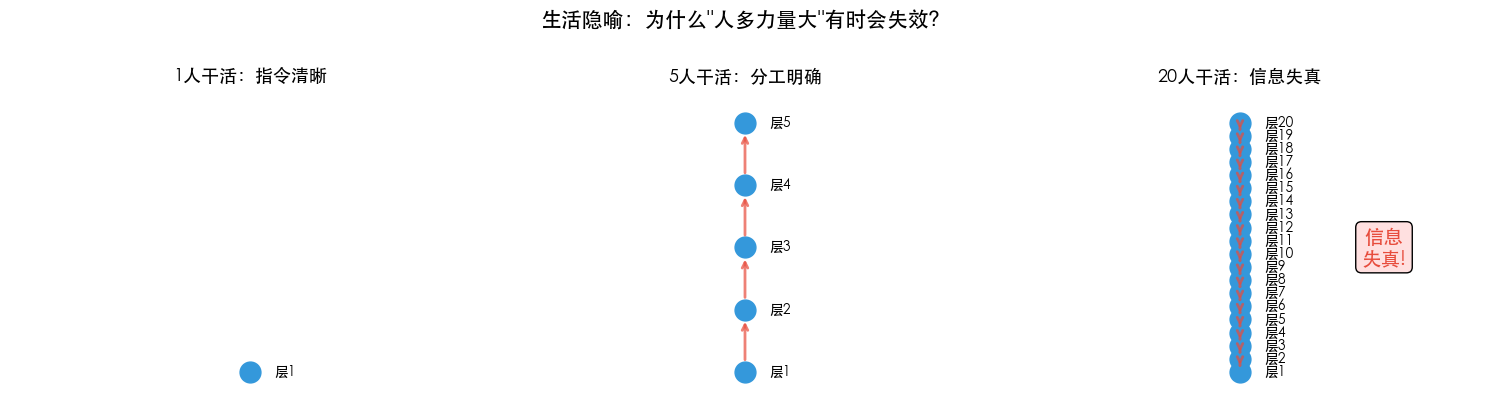</p>*信息传递失真示意图*

## 3. 代码实验室：见证退化问题让我们用最简单的数据，亲手复现这个"越深越蠢"的现象。

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.1 准备数据：一个简单的分类任务我们用经典的螺旋数据集——它需要非线性决策边界，但又不至于太难。

In [ ]:
def make_spiral_data(n_samples=300, noise=0.3):    """生成螺旋形分类数据"""    np.random.seed(42)    n = n_samples // 2    theta_class0 = np.linspace(0, 2 * np.pi, n) + np.random.randn(n) * noise    theta_class1 = np.linspace(0, 2 * np.pi, n) + np.random.randn(n) * noise + np.pi    r_class0 = theta_class0 / (2 * np.pi) + np.random.randn(n) * noise * 0.3    r_class1 = theta_class1 / (2 * np.pi) + np.random.randn(n) * noise * 0.3    x_class0 = np.column_stack([r_class0 * np.cos(theta_class0), r_class0 * np.sin(theta_class0)])    x_class1 = np.column_stack([r_class1 * np.cos(theta_class1), r_class1 * np.sin(theta_class1)])    X = np.vstack([x_class0, x_class1]).astype(np.float32)    y = np.concatenate([np.zeros(n), np.ones(n)]).astype(np.float32)    return torch.tensor(X), torch.tensor(y).unsqueeze(1)X_spiral, y_spiral = make_spiral_data()print(f"数据形状: X={X_spiral.shape}, y={y_spiral.shape}")print(f"类别分布: 类别0={int((y_spiral==0).sum())}, 类别1={int((y_spiral==1).sum())}")

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))for label, color, marker in [(0, '#e74c3c', 'x'), (1, '#2ecc71', 'o')]:    mask = y_spiral.squeeze() == label    ax.scatter(X_spiral[mask, 0], X_spiral[mask, 1],               c=color, marker=marker, s=30, alpha=0.7,               label=f'类别 {int(label)}')ax.set_title('螺旋数据集：需要非线性边界', fontsize=14)ax.legend(fontsize=12)ax.grid(True, alpha=0.3)plt.tight_layout()plt.show()

### 3.2 搭建"普通网络"（Plain Network）我们搭建两个网络：一个浅的（8 层），一个深的（32 层），其他配置完全一样。

In [ ]:
class PlainBlock(nn.Module):    """一个普通的残差块（不带跳跃连接）"""    def __init__(self, hidden_size):        super().__init__()        self.block = nn.Sequential(            nn.Linear(hidden_size, hidden_size),            nn.BatchNorm1d(hidden_size),            nn.ReLU(),            nn.Linear(hidden_size, hidden_size),            nn.BatchNorm1d(hidden_size),        )        self.relu = nn.ReLU()    def forward(self, x):        out = self.block(x)        out = self.relu(out)        return outclass PlainNet(nn.Module):    """普通深层网络：没有跳跃连接"""    def __init__(self, input_size=2, hidden_size=64, num_blocks=4, output_size=1):        super().__init__()        layers = [nn.Linear(input_size, hidden_size), nn.ReLU()]        for _ in range(num_blocks):            layers.append(PlainBlock(hidden_size))        layers.append(nn.Linear(hidden_size, output_size))        layers.append(nn.Sigmoid())        self.net = nn.Sequential(*layers)    def forward(self, x):        return self.net(x)

### 3.3 训练函数

In [ ]:
def train_model(model, X, y, epochs=300, lr=0.01, verbose=True):    """训练模型并返回训练损失历史"""    optimizer = torch.optim.Adam(model.parameters(), lr=lr)    loss_fn = nn.BCELoss()    losses = []    for epoch in range(epochs):        predicted_probability = model(X)        loss = loss_fn(predicted_probability, y)        optimizer.zero_grad()        loss.backward()        optimizer.step()        losses.append(loss.item())        if verbose and (epoch + 1) % 100 == 0:            accuracy = ((predicted_probability > 0.5).float() == y).float().mean()            print(f"  Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Acc: {accuracy.item():.4f}")    return losses

### 3.4 对决：浅层 vs 深层

In [ ]:
print("=" * 50)print("浅层网络 (4 个 Block, 约 8 层)")print("=" * 50)torch.manual_seed(42)shallow_net = PlainNet(num_blocks=4)shallow_losses = train_model(shallow_net, X_spiral, y_spiral, epochs=300)print()print("=" * 50)print("深层网络 (16 个 Block, 约 32 层)")print("=" * 50)torch.manual_seed(42)deep_net = PlainNet(num_blocks=16)deep_losses = train_model(deep_net, X_spiral, y_spiral, epochs=300)

### 3.5 结果对比

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))axes[0].plot(shallow_losses, label='浅层 (4 Blocks)', color='#3498db', alpha=0.8)axes[0].plot(deep_losses, label='深层 (16 Blocks)', color='#e74c3c', alpha=0.8)axes[0].set_xlabel('Epoch', fontsize=12)axes[0].set_ylabel('Training Loss', fontsize=12)axes[0].set_title('训练损失对比：越深越难训练', fontsize=14)axes[0].legend(fontsize=12)axes[0].grid(True, alpha=0.3)shallow_acc = ((shallow_net(X_spiral) > 0.5).float() == y_spiral).float().mean()deep_acc = ((deep_net(X_spiral) > 0.5).float() == y_spiral).float().mean()bar_colors = ['#3498db', '#e74c3c']bars = axes[1].bar(['浅层 (4 Blocks)', '深层 (16 Blocks)'],                    [shallow_acc.item(), deep_acc.item()],                    color=bar_colors, alpha=0.8, edgecolor='black')axes[1].set_ylabel('Training Accuracy', fontsize=12)axes[1].set_title('训练准确率对比', fontsize=14)axes[1].set_ylim(0, 1.0)for bar, acc in zip(bars, [shallow_acc.item(), deep_acc.item()]):    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,                 f'{acc:.2%}', ha='center', fontsize=14, fontweight='bold')axes[1].grid(True, alpha=0.3, axis='y')plt.tight_layout()plt.show()

### 解读你看到了什么？- **浅层网络**：损失稳步下降，准确率逐渐升高- **深层网络**：损失下降缓慢，甚至卡住不动，准确率明显更低**这就是退化问题**：网络变深了，反而学得更差了。---

## 4. 关键区分：退化 ≠ 过拟合很多人会混淆这两个概念，让我们彻底搞清楚：| | 退化问题 (Degradation) | 过拟合 (Overfitting) ||---|---|---|| **训练集表现** | 差 | 好 || **测试集表现** | 差 | 差 || **根本原因** | 信息在深层传递中丢失 | 模型死记硬背训练数据 || **解决办法** | 残差连接（ResNet） | 正则化、Dropout、更多数据 |**退化问题的本质**：深层网络连训练集都学不好。它不是"学歪了"，而是"学不动了"。

In [ ]:
print("退化问题 vs 过拟合：关键区别\n")print("过拟合：训练集准确率 99%，测试集准确率 60%")print("       -> 模型记住了训练数据，但不会举一反三")print()print("退化问题：训练集准确率 70%，测试集准确率 65%")print("       -> 模型连训练数据都没学好，不是记多了，是学不会")

---

## 5. 几何直觉：信息在传递中"走样"想象你在玩"传话游戏"：

<p align="center">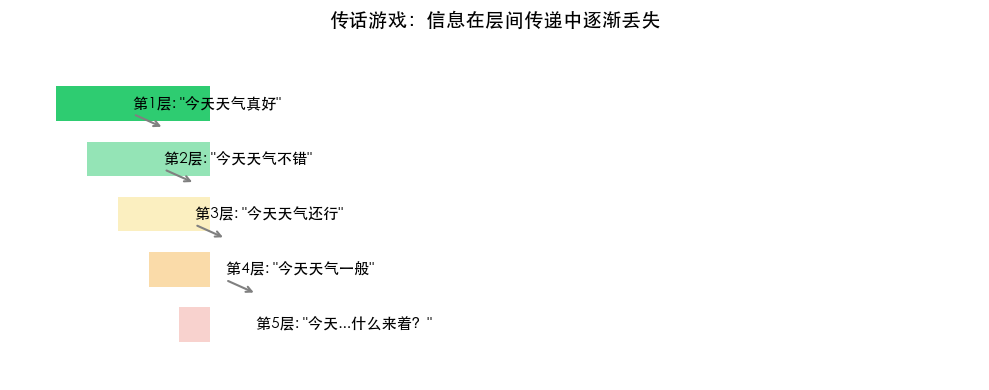</p>*传话游戏信息衰减示意图*

原始信息: "今天天气真好"  ↓ 第1个人"今天天气不错"  ↓ 第2个人"今天天气还行"  ↓ 第3个人"今天天气一般"  ...  ↓ 第20个人"今天...什么来着？"

每一层网络都在对信息做变换。如果变换是"恰到好处"的，信息会越来越丰富。但如果变换"走偏了"一点点，经过几十层的累积，原始信号就被彻底淹没了。**深层网络的困境**：每一层都需要学会"既保留有用信息，又添加新信息"。层数越多，这个任务越难。如果有一种方法，能让信息"跳过"中间那些可能搞砸的层，直接传到后面去呢？> 这个想法，就是明天我们要讲的——**残差连接**。---

## 今日结语今天我们见证了一个反直觉的现象：**网络越深，反而越蠢**。这不是过拟合，而是退化——信息在层层传递中逐渐丢失，就像传话游戏一样。这个"死局"困扰了整个深度学习界，直到 2015 年，一个名叫何恺明的年轻人，用一行极其简单的代码打破了僵局。那行代码是什么？明天揭晓。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 盖楼——楼层越高视野越好 | 深度假设——网络越深能力越强 || 人多反而乱——信息在传递中失真 | 退化问题——深层网络训练误差反而更高 || 传话游戏——信息层层走样 | 梯度消失/信号衰减——信息在层间传递中丢失 || 连训练数据都学不好 | 退化问题（不是过拟合！） || 训练数据学得太好但不会举一反三 | 过拟合 || 每一层都是一次"信息加工" | 前向传播中的逐层变换 || 信息"抄近道"跳过中间层 | 残差连接/跳跃连接（预告！） |